# Bengal 2021 vs 2026 - four charts

Four things worth seeing rather than reading: how votes turned into seats, where
the swing was deepest, whether the turnout rise is real, and why so many seats
changed hands.

Data comes from `bengal_elections.db`, built by `src/clean.py` and `src/load_db.py`.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../bengal_elections.db")

# same look for every chart
plt.rcParams.update({"figure.figsize": (8, 5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREY = "#b8b6b0"

## 1. Votes in, seats out

First-past-the-post rewards whoever is ahead in each seat, by any amount. So a
party's share of seats doesn't have to look anything like its share of votes.

In [2]:
q = '''
WITH v AS (SELECT party, SUM(total_votes)*100.0/(SELECT SUM(total_votes) FROM results WHERE year=2026) AS vote_share
           FROM results WHERE year=2026 GROUP BY party),
     s AS (SELECT winner_party AS party, COUNT(*)*100.0/293 AS seat_share
           FROM winners WHERE year=2026 GROUP BY winner_party)
SELECT v.party, v.vote_share, COALESCE(s.seat_share, 0) AS seat_share
FROM v LEFT JOIN s ON s.party = v.party
WHERE v.vote_share >= 1 ORDER BY v.vote_share
'''
a = pd.read_sql(q, conn)   # 293 not 294 - Falta held no poll
a.round(1)

,party,vote_share,seat_share
0,IND,1.2,0.0
1,AISF,1.5,0.3
2,INC,3.0,0.7
3,CPI(M),4.5,0.3
4,TMC,41.1,27.3
5,BJP,46.2,70.6


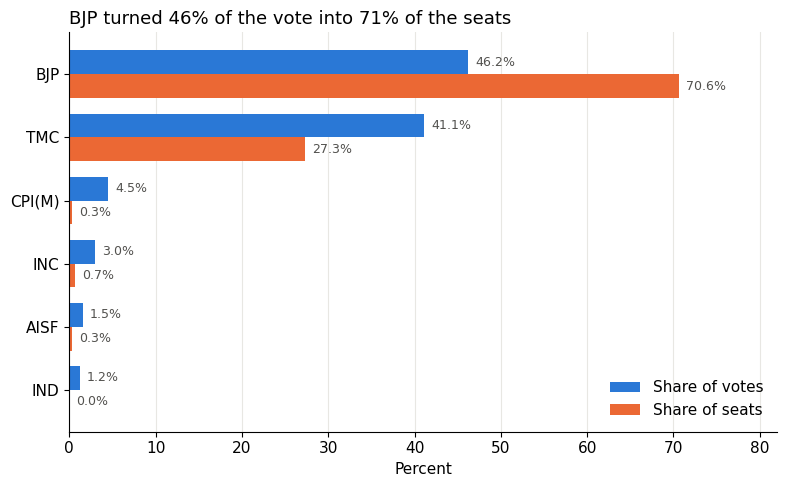

In [3]:
y = np.arange(len(a))
h = 0.38

fig, ax = plt.subplots()
ax.barh(y + h/2, a.vote_share, h, color=BLUE, label="Share of votes")
ax.barh(y - h/2, a.seat_share, h, color=ORANGE, label="Share of seats")

for i, row in a.iterrows():
    ax.text(row.vote_share + 0.8, i + h/2, f"{row.vote_share:.1f}%", va="center", fontsize=9, color="#52514e")
    ax.text(row.seat_share + 0.8, i - h/2, f"{row.seat_share:.1f}%", va="center", fontsize=9, color="#52514e")

ax.set_yticks(y)
ax.set_yticklabels(a.party)
ax.set_xlim(0, 82)
ax.set_xlabel("Percent")
ax.grid(axis="x", color="#e8e7e3", linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
ax.set_title("BJP turned 46% of the vote into 71% of the seats", fontsize=13, loc="left")

fig.tight_layout()
fig.savefig("../figures/vote_vs_seat_share.png", dpi=150)
plt.show()

CPI(M) is the other end of the same effect - 4.5% of the vote and one seat, because
coming third everywhere wins nothing.

## 2. Where the swing was deepest

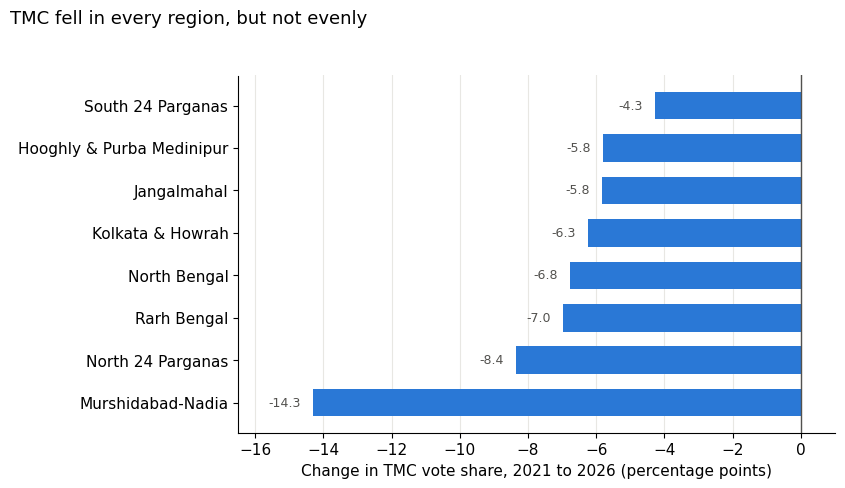

In [4]:
q = '''
WITH r AS (SELECT c.region, v.year,
                  SUM(CASE WHEN v.party='TMC' THEN v.total_votes ELSE 0 END)*100.0/SUM(v.total_votes) AS tmc
           FROM v_results v JOIN constituencies c ON c.ac_no=v.ac_no GROUP BY 1,2)
SELECT region,
       MAX(CASE WHEN year=2026 THEN tmc END) - MAX(CASE WHEN year=2021 THEN tmc END) AS swing
FROM r GROUP BY region ORDER BY swing
'''
b = pd.read_sql(q, conn)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(b.region, b.swing, color=BLUE, height=0.65)
for i, row in b.iterrows():
    ax.text(row.swing - 0.35, i, f"{row.swing:.1f}", va="center", ha="right", fontsize=9, color="#52514e")

ax.axvline(0, color="#52514e", linewidth=1)
ax.set_xlim(-16.5, 1)
ax.set_xlabel("Change in TMC vote share, 2021 to 2026 (percentage points)")
ax.grid(axis="x", color="#e8e7e3", linewidth=0.8)
ax.set_axisbelow(True)
# title on the figure, not the axes - the region labels are wide
fig.suptitle("TMC fell in every region, but not evenly", fontsize=13, x=0.01, ha="left", y=0.97)

fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("../figures/regional_swing.png", dpi=150)
plt.show()

Murshidabad-Nadia moved more than three times as far as South 24 Parganas. It
wasn't a uniform national-style swing.

## 3. Did turnout actually go up?

Turnout reads 93.6% in 2026 against 82.2% in 2021. But the electoral roll shrank at
the same time, and turnout is votes divided by registered voters - so a smaller roll
pushes the percentage up on its own.

If that's what happened, the seats where the roll shrank most should be the seats
where turnout "rose" most. One dot per seat, Falta excluded.

In [5]:
q = '''
SELECT e.ac_no, c.region,
       MAX(CASE WHEN e.year=2021 THEN e.total_electors END) AS roll_2021,
       MAX(CASE WHEN e.year=2026 THEN e.total_electors END) AS roll_2026,
       MAX(CASE WHEN e.year=2021 THEN e.turnout_pct END) AS turnout_2021,
       MAX(CASE WHEN e.year=2026 THEN e.turnout_pct END) AS turnout_2026
FROM electorate e
JOIN constituencies c ON c.ac_no = e.ac_no
WHERE e.ac_no <> 144
GROUP BY e.ac_no, c.region
'''
t = pd.read_sql(q, conn)

t["roll_change"] = (t.roll_2026 - t.roll_2021) / t.roll_2021 * 100
t["turnout_change"] = t.turnout_2026 - t.turnout_2021

r = t.roll_change.corr(t.turnout_change)
print("correlation:", round(r, 3))
t[["roll_change", "turnout_change"]].describe().round(2)

correlation: -0.836


,roll_change,turnout_change
count,293.00,293.00
mean,-7.06,11.47
std,7.43,5.19
min,-39.14,3.62
25%,-11.07,8.03
50%,-5.96,10.47
75%,-1.75,13.59
max,4.70,37.06


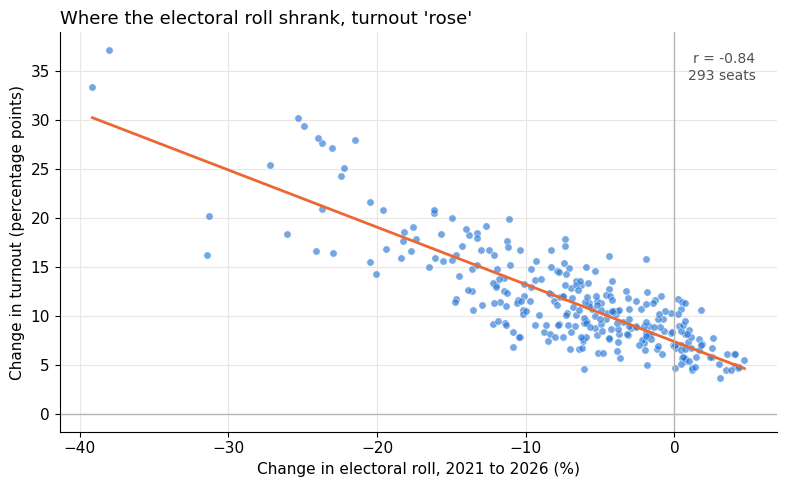

In [6]:
fig, ax = plt.subplots()
ax.scatter(t.roll_change, t.turnout_change, s=28, color=BLUE, alpha=0.65,
           edgecolors="white", linewidths=0.5)

# trend line
slope, intercept = np.polyfit(t.roll_change, t.turnout_change, 1)
xs = np.array([t.roll_change.min(), t.roll_change.max()])
ax.plot(xs, slope * xs + intercept, color=ORANGE, linewidth=2)

ax.axhline(0, color=GREY, linewidth=1)
ax.axvline(0, color=GREY, linewidth=1)
ax.grid(color="#e8e7e3", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel("Change in electoral roll, 2021 to 2026 (%)")
ax.set_ylabel("Change in turnout (percentage points)")
ax.set_title("Where the electoral roll shrank, turnout 'rose'", fontsize=13, loc="left")
ax.text(0.97, 0.95, f"r = {r:.2f}\n{len(t)} seats", transform=ax.transAxes,
        ha="right", va="top", color="#52514e", fontsize=10)

fig.tight_layout()
fig.savefig("../figures/turnout_vs_roll.png", dpi=150)
plt.show()

r = -0.84 across 293 seats. The seats that lost the most voters from the register
are the seats where turnout climbed most - which is what you'd expect if the rise is
mostly a smaller denominator rather than more people voting.

This doesn't explain *why* the roll shrank. That still needs checking against
whatever revision the Election Commission ran.

## 4. Why did so many seats flip?

TMC lost 7.4 points of vote share and 135 seats. That sounds disproportionate until
you look at how close the 2021 seats were.

A swing of 7.4 points moves a margin by roughly 15 - the winner loses what the
challenger gains. So every seat held by less than 15 points was in play.

In [7]:
m21 = pd.read_sql("SELECT margin_pct_polled FROM winners WHERE year=2021", conn)
THRESHOLD = 15

n = (m21.margin_pct_polled < THRESHOLD).sum()
print(n, "of 294 seats under", THRESHOLD, "points =", round(n / 294 * 100), "%")
m21.margin_pct_polled.describe().round(2)

197 of 294 seats under 15 points = 67 %


count    294.00
mean      13.55
std       11.49
min        0.02
25%        5.11
50%       10.72
75%       18.03
max       62.70
Name: margin_pct_polled, dtype: float64

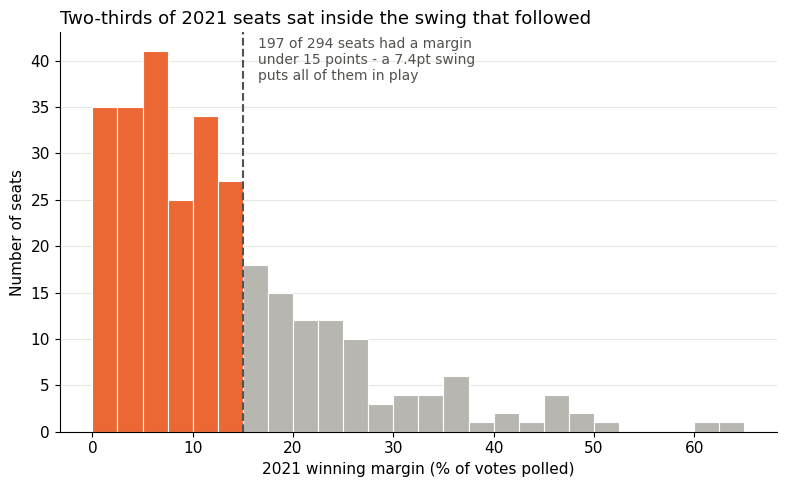

In [8]:
fig, ax = plt.subplots()
bins = np.arange(0, 67.5, 2.5)   # 15 lands on a bin edge
counts, bins, patches = ax.hist(m21.margin_pct_polled, bins=bins,
                                color=GREY, edgecolor="white", linewidth=0.8)

# colour the bars below the threshold
for patch, right_edge in zip(patches, bins[1:]):
    if right_edge <= THRESHOLD:
        patch.set_facecolor(ORANGE)

ax.axvline(THRESHOLD, color="#52514e", linestyle="--", linewidth=1.5)
ax.text(THRESHOLD + 1.5, ax.get_ylim()[1] * 0.88,
        f"{n} of 294 seats had a margin\nunder 15 points - a 7.4pt swing\nputs all of them in play",
        fontsize=10, color="#52514e")

ax.grid(axis="y", color="#e8e7e3", linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlabel("2021 winning margin (% of votes polled)")
ax.set_ylabel("Number of seats")
ax.set_title("Two-thirds of 2021 seats sat inside the swing that followed",
             fontsize=13, loc="left")

fig.tight_layout()
fig.savefig("../figures/margin_distribution_2021.png", dpi=150)
plt.show()

197 of 294 seats were held by under 15 points. That's why a 7.4-point swing turned
into a 135-seat loss - first-past-the-post doesn't care how big a margin is, only
who is ahead, so a thin lead counts the same as a landslide until it doesn't.

In [9]:
conn.close()